# Quantum-Enhanced GAN Research Notebook

## Research context

This notebook supports the HQCGAN research project completed under Singapore Polytechnic, School of Computing, Diploma in Applied AI and Analytics, for Deep Learning (`ST1504`) CA2 Part C, AY25/26 Year 2 Semester 1.

Author: Goh Kun Ming, DAAA student, ORCID: https://orcid.org/0009-0008-7666-781X

Supervising lecturer: Lecturer Gerald Chua Deng Xiang

Public paper: https://arxiv.org/abs/2508.09209


## Reproducibility and imports

The notebook fixes a random seed for NumPy and TensorFlow. Full experiment runs should also record the Python version, dependency versions, hardware, simulator backend, and the exact configuration used.


In [13]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.linalg
import optuna
import tensorflow as tf
from tensorflow.keras import Sequential, Model, Input
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.utils import resample

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## Dataset preparation

MNIST is filtered to the binary task used in the study: digits `0` and `1`. Images are converted to `float32` and normalised to `[-1, 1]` so the generator can use a `tanh` output layer.


In [14]:
# Cell 2: MNIST Loading & [-1, 1] Normalisation

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Filter for 0 and 1
mask = (y_train == 0) | (y_train == 1)
x_train_bin = x_train[mask].astype('float32')

# Normalize to [-1, 1]
x_train_bin = (x_train_bin / 127.5) - 1.0

y_train_bin = y_train[mask]


## Original class distribution

The chart below checks the class balance before downsampling. This matters because imbalance can make GAN training and downstream FID/KID comparisons less interpretable.


C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\2703551405.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\2703551405.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Digit 0", "Digit 1"], fontsize=12)


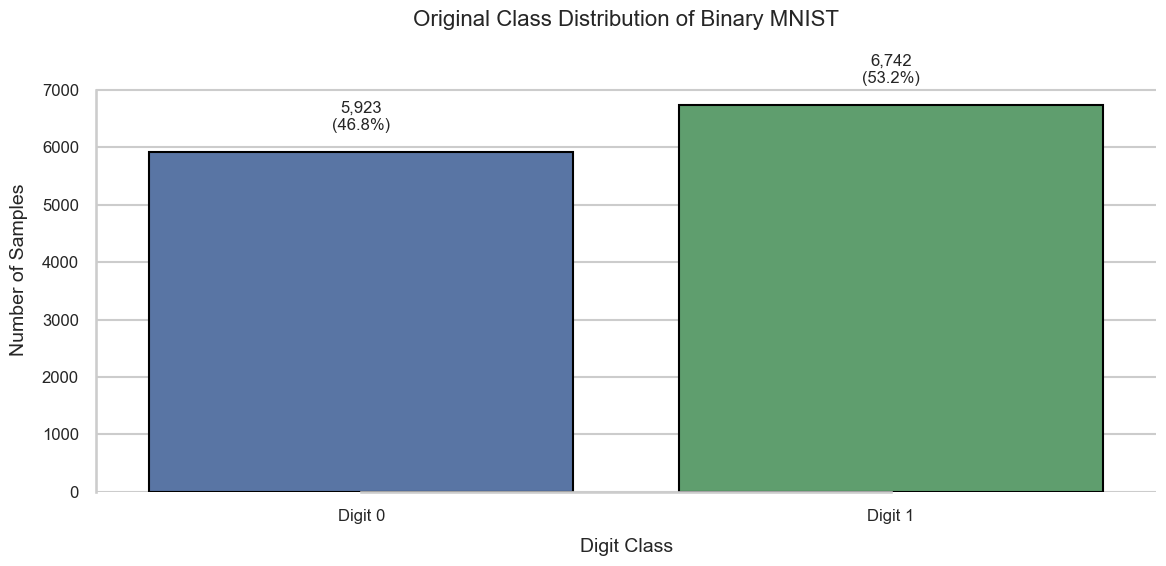

In [15]:
# Assume y_train_bin is defined
df = pd.DataFrame({'Digit': y_train_bin})

# Compute counts and percentages
counts = df['Digit'].value_counts().sort_index()
percentages = df['Digit'].value_counts(normalize=True).sort_index() * 100

# Seaborn styling
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12,6))

# Plot with custom palette
ax = sns.countplot(
    data=df,
    x='Digit',
    palette=['#4C72B0', '#55A868'],
    edgecolor='black'
)

# Annotate each bar
y_max = counts.max()
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(
        i, count + y_max*0.05,            # place at 5% above max bar
        f"{count:,}\n({pct:.1f}%)",       
        ha='center', va='bottom',        
        fontsize=12
    )

# Labels and title
ax.set_title("Original Class Distribution of Binary MNIST", fontsize=16, pad=15)
ax.set_xlabel("Digit Class", fontsize=14, labelpad=10)
ax.set_ylabel("Number of Samples", fontsize=14, labelpad=10)
ax.set_xticklabels(["Digit 0", "Digit 1"], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Increase y‐limit by 10%
ax.set_ylim(0, y_max * 1.15)

# Clean up spines
sns.despine(trim=True)

plt.tight_layout()
plt.show()

## Balanced training set

The larger class is downsampled with a fixed seed. This produces a parity dataset for comparing classical and hybrid quantum-classical GAN variants.


In [16]:
x_0 = x_train_bin[y_train_bin == 0]
x_1 = x_train_bin[y_train_bin == 1]
min_count = min(len(x_0), len(x_1))

x_0_down = resample(x_0, n_samples=min_count, random_state=RANDOM_SEED, replace=False)
x_1_down = resample(x_1, n_samples=min_count, random_state=RANDOM_SEED, replace=False)

x_train_bal = np.vstack([x_0_down, x_1_down])
y_train_bal = np.array([0] * min_count + [1] * min_count)

rng = np.random.default_rng(RANDOM_SEED)
perm = rng.permutation(len(y_train_bal))
x_train_bal = x_train_bal[perm]
y_train_bal = y_train_bal[perm]


## Balanced class distribution

This plot verifies that the downsampled dataset contains the same number of digit `0` and digit `1` samples.


C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\457498034.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\457498034.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Digit 0", "Digit 1"], fontsize=12)


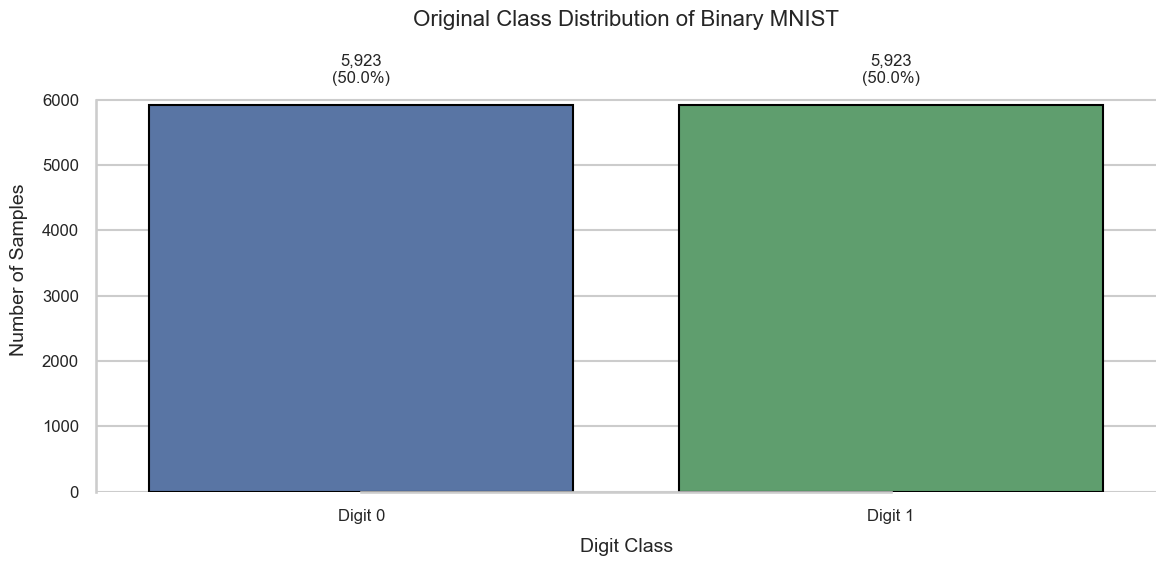

In [17]:
# Assume y_train_bin is defined
df = pd.DataFrame({'Digit': y_train_bal})

# Compute counts and percentages
counts = df['Digit'].value_counts().sort_index()
percentages = df['Digit'].value_counts(normalize=True).sort_index() * 100

# Seaborn styling
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12,6))

# Plot with custom palette
ax = sns.countplot(
    data=df,
    x='Digit',
    palette=['#4C72B0', '#55A868'],
    edgecolor='black'
)

# Annotate each bar
y_max = counts.max()
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(
        i, count + y_max*0.05,            # place at 5% above max bar
        f"{count:,}\n({pct:.1f}%)",       
        ha='center', va='bottom',        
        fontsize=12
    )

# Labels and title
ax.set_title("Balanced Class Distribution of Binary MNIST", fontsize=16, pad=15)
ax.set_xlabel("Digit Class", fontsize=14, labelpad=10)
ax.set_ylabel("Number of Samples", fontsize=14, labelpad=10)
ax.set_xticklabels(["Digit 0", "Digit 1"], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Increase y‐limit by 10%
ax.set_ylim(0, y_max * 1.15)

# Clean up spines
sns.despine(trim=True)

plt.tight_layout()
plt.show()


## Metric setup: FID

FID is computed from InceptionV3 activations. Generated images should be passed to `calculate_fid` in the notebook's native `[-1, 1]` MNIST shape `(n, 28, 28)`; preprocessing handles clipping, channel expansion, resizing, and Inception scaling in one place.


In [18]:
# Initialize InceptionV3
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))


def preprocess_for_inception(imgs):
    """Convert MNIST-like images in [-1, 1] to InceptionV3 input tensors."""
    imgs = np.asarray(imgs, dtype=np.float32)
    if imgs.ndim == 4 and imgs.shape[-1] == 1:
        imgs = imgs[..., 0]
    if imgs.ndim != 3:
        raise ValueError(f"Expected images with shape (n, 28, 28); got {imgs.shape}")

    # Scale from [-1, 1] to [0, 255]
    imgs = np.clip((imgs + 1.0) * 127.5, 0.0, 255.0)
    # Expand to 3 channels
    imgs = np.expand_dims(imgs, axis=-1)        # (n, 28, 28, 1)
    imgs = np.repeat(imgs, 3, axis=-1)          # (n, 28, 28, 3)
    # Resize to Inception input size
    imgs_resized = tf.image.resize(imgs, [299, 299]).numpy()
    # Preprocess as Inception expects
    return preprocess_input(imgs_resized)


# Sample real images for FID (still uses x_train_bal in [-1, 1])
n_fid = min(500, len(x_train_bal))
idx_fid = np.random.choice(len(x_train_bal), n_fid, replace=False)
real_images_fid = x_train_bal[idx_fid]
real_acts = inception_model.predict(preprocess_for_inception(real_images_fid), verbose=0)


def calculate_fid(acts_real, fake_imgs):
    fake_acts = inception_model.predict(preprocess_for_inception(fake_imgs), verbose=0)
    mu1, sigma1 = np.mean(acts_real, axis=0), np.cov(acts_real, rowvar=False)
    mu2, sigma2 = np.mean(fake_acts, axis=0), np.cov(fake_acts, rowvar=False)
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(max(fid, 0.0))


## Generator model

The generator maps latent vectors to `28 x 28` images. The `tanh` output matches the `[-1, 1]` normalisation used during preprocessing.


In [19]:
def build_generator(latent_dim=100, hidden_units=128):
    model = Sequential([
        Dense(hidden_units, input_dim=latent_dim),
        LeakyReLU(0.2),
        Dense(784, activation='tanh'),   # <-- tanh instead of sigmoid
        Reshape((28,28))
    ])
    return model

## Discriminator model

The discriminator is a compact fully connected classifier for distinguishing real and generated binary MNIST images.


In [20]:
def build_discriminator():
    """Fully-connected discriminator for 28x28 images."""
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

## Single-step training helper

This helper performs one discriminator update and one generator update. The longer training loop below is preferred for tracked experiments because it records histories and FID-based early stopping.


In [21]:
def train_one_step(generator, discriminator, combined, latent_dim, batch_size):
    """Train discriminator and generator for one batch, return generated samples."""
    # Sample real
    idx = np.random.randint(0, len(x_train_bal), batch_size)
    real_imgs = x_train_bal[idx]
    # Generate fake
    noise = np.random.normal(0,1,(batch_size, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)
    # Train D
    discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))
    # Train G
    noise = np.random.normal(0,1,(batch_size, latent_dim))
    combined.train_on_batch(noise, np.ones((batch_size,1)))
    return fake_imgs

## Training loop

The training loop records generator and discriminator losses, periodically visualises generated samples, evaluates FID, and optionally saves the best weights. FID preprocessing is centralized in `calculate_fid` to avoid double-scaling generated images.


In [22]:
def train(dataset, epochs, generator, discriminator, gen_optimizer, disc_optimizer,
          latent_dim, save_path=None, steps_per_epoch=None, fid_interval=1, patience=12,
          display_interval=5):

    # Prepare FID holdout: uses real_images_fid and real_acts from previous cell
    noise_val = tf.random.normal([len(real_images_fid), latent_dim])
    noise_val = tf.math.l2_normalize(noise_val, axis=1)

    best_fid = float('inf')
    no_improve = 0

    gen_loss_history, disc_loss_history = [], []

    for epoch in range(1, epochs + 1):
        print()
        print(f"Epoch {epoch}/{epochs}")
        epoch_gen_losses, epoch_disc_losses = [], []

        for step, real_batch in enumerate(dataset):
            if steps_per_epoch and step >= steps_per_epoch:
                break

            current_batch_size = tf.shape(real_batch)[0]

            # Train discriminator
            noise = tf.random.normal([current_batch_size, latent_dim])
            fake_batch = generator(noise, training=True)

            with tf.GradientTape() as tape:
                real_logits = discriminator(real_batch, training=True)
                fake_logits = discriminator(fake_batch, training=True)
                d_loss_real = tf.keras.losses.BinaryCrossentropy(from_logits=False)(
                    tf.ones_like(real_logits), real_logits)
                d_loss_fake = tf.keras.losses.BinaryCrossentropy(from_logits=False)(
                    tf.zeros_like(fake_logits), fake_logits)
                d_loss = (d_loss_real + d_loss_fake) / 2
            grads = tape.gradient(d_loss, discriminator.trainable_variables)
            disc_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
            epoch_disc_losses.append(d_loss.numpy())

            # Train generator
            noise = tf.random.normal([current_batch_size, latent_dim])
            with tf.GradientTape() as tape:
                fake = generator(noise, training=True)
                pred = discriminator(fake, training=False)
                g_loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)(
                    tf.ones_like(pred), pred)
            grads = tape.gradient(g_loss, generator.trainable_variables)
            gen_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
            epoch_gen_losses.append(g_loss.numpy())

        if not epoch_gen_losses or not epoch_disc_losses:
            raise ValueError(
                "No training batches were processed. Check dataset and steps_per_epoch."
            )

        # Epoch metrics
        avg_g = np.mean(epoch_gen_losses)
        avg_d = np.mean(epoch_disc_losses)
        gen_loss_history.append(avg_g)
        disc_loss_history.append(avg_d)
        print(f"Generator Loss: {avg_g:.4f} | Discriminator Loss: {avg_d:.4f}")

        # Display samples
        if epoch % display_interval == 0:
            samples_noise = tf.random.normal([16, latent_dim])
            samples = generator(samples_noise, training=False).numpy().reshape(-1, 28, 28)
            fig, axs = plt.subplots(4, 4, figsize=(4, 4))
            cnt = 0
            for i in range(4):
                for j in range(4):
                    axs[i, j].imshow(samples[cnt], cmap='gray')
                    axs[i, j].axis('off')
                    cnt += 1
            plt.suptitle(f"Epoch {epoch}")
            plt.show()

        # FID evaluation and early stopping
        if epoch % fid_interval == 0:
            fake_images = generator(noise_val, training=False).numpy().reshape(-1, 28, 28)
            fid_val = calculate_fid(real_acts, fake_images)
            print(f"Epoch {epoch} -> Val FID: {fid_val:.2f}")

            if fid_val < best_fid:
                best_fid = fid_val
                no_improve = 0
                if save_path:
                    save_dir = Path(save_path)
                    save_dir.mkdir(parents=True, exist_ok=True)
                    generator.save_weights(save_dir / "best_gen.weights.h5")
                    discriminator.save_weights(save_dir / "best_disc.weights.h5")
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"No FID improvement for {patience} epochs. Stopping.")
                    break

    return avg_g, gen_loss_history, disc_loss_history, best_fid


## Hyperparameter objective

Optuna searches over latent dimensionality, hidden units, and learning rate. Long optimisation runs should be treated as experiment jobs and tracked with the config, seed, and output artifacts.


In [23]:
def objective(trial):
    # 1. Suggest hyperparameters
    latent_dim   = trial.suggest_int("latent_dim", 64, 200)
    hidden_units = trial.suggest_categorical("hidden_units", [64, 128, 256])
    lr           = trial.suggest_float("learning_rate", 1e-5, 5e-3, log=True)

    # 2. Build & compile discriminator
    discriminator = build_discriminator()
    disc_opt = Adam(learning_rate=lr)
    discriminator.compile(loss="binary_crossentropy", optimizer=disc_opt)

    # 3. Build generator
    generator = build_generator(latent_dim, hidden_units)
    gen_opt = Adam(learning_rate=lr)

    # 4. Prepare tf.data.Dataset
    ds = tf.data.Dataset.from_tensor_slices(x_train_bal)\
                       .shuffle(1024)\
                       .batch(64)\
                       .prefetch(tf.data.AUTOTUNE)

    # 5. Call train() → unpack best_fid
    _, gen_hist, disc_hist, best_fid = train(
        dataset=ds,
        epochs=5000,
        generator=generator,
        discriminator=discriminator,
        gen_optimizer=gen_opt,
        disc_optimizer=disc_opt,
        latent_dim=latent_dim,
        save_path=None,
        steps_per_epoch=None,
        fid_interval=1,
        patience=50,
        display_interval=100
    )

    # 6. Return the best_fid
    return best_fid


## Study execution

The study is persisted to SQLite so interrupted optimisation can resume. The database is a generated local artifact and should not be committed.


In [24]:
# 1. Create (or load) the study with SQLite storage
study = optuna.create_study(
    study_name="classical_gan_balanced_fid",
    storage="sqlite:///classical_gan_balanced_fid.db",
    load_if_exists=True,
    direction="minimize"
)

# 2. Define how many trials you want in total
n_trials = 20

# 3. Run optimization only if we haven’t already done enough trials
if len(study.trials) < n_trials:
    study.optimize(
        objective,
        n_trials = n_trials - len(study.trials)
    )
else:
    print(f"Completed {len(study.trials)} trials already — skipping optimization.")

# 4. Retrieve and print the best trial
best = study.best_trial
print("Best FID:", best.value)
print("Best Hyperparameters:")
for key, val in best.params.items():
    print(f"  {key}: {val}")

[I 2025-07-17 01:58:44,087] Using an existing study with name 'classical_gan_balanced_fid' instead of creating a new one.



Epoch 1/5000
Generator Loss: 9.1796 | Discriminator Loss: 0.3336
Epoch 1 → Val FID: 204392.19

Epoch 2/5000
Generator Loss: 4.5842 | Discriminator Loss: 0.1064
Epoch 2 → Val FID: 321762.32

Epoch 3/5000
Generator Loss: 5.6450 | Discriminator Loss: 0.1111
Epoch 3 → Val FID: 2020704.10

Epoch 4/5000
Generator Loss: 7.5706 | Discriminator Loss: 0.1447
Epoch 4 → Val FID: 4305252.04

Epoch 5/5000
Generator Loss: 7.4622 | Discriminator Loss: 0.2586
Epoch 5 → Val FID: 598416.18

Epoch 6/5000
Generator Loss: 7.3780 | Discriminator Loss: 0.1701
Epoch 6 → Val FID: 6143513.50

Epoch 7/5000
Generator Loss: 6.9230 | Discriminator Loss: 0.2247
Epoch 7 → Val FID: 6511680.90

Epoch 8/5000
Generator Loss: 7.0918 | Discriminator Loss: 0.4253
Epoch 8 → Val FID: 9710799.45

Epoch 9/5000
Generator Loss: 6.1017 | Discriminator Loss: 0.3033
Epoch 9 → Val FID: 3598366.41

Epoch 10/5000
Generator Loss: 4.8225 | Discriminator Loss: 0.3510


[W 2025-07-17 02:04:36,668] Trial 6 failed with parameters: {'latent_dim': 69, 'hidden_units': 128, 'learning_rate': 0.001725656303375255} because of the following error: ResourceExhaustedError().
Traceback (most recent call last):
  File "C:\Users\kunmi\anaconda3\envs\gpu_env\lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\11881466.py", line 23, in objective
    _, gen_hist, disc_hist, best_fid = train(
  File "C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\1317853186.py", line 76, in train
    fid_val = calculate_fid(real_acts, fake_res.numpy())
  File "C:\Users\kunmi\AppData\Local\Temp\ipykernel_90996\2303054314.py", line 22, in calculate_fid
    fake_acts = inception_model.predict(preprocess_for_inception(fake_imgs), verbose=0)
  File "C:\Users\kunmi\anaconda3\envs\gpu_env\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
    raise e.with_t

ResourceExhaustedError: Graph execution error:

SameWorkerRecvDone unable to allocate output tensor. Key: /job:localhost/replica:0/task:0/device:CPU:0;654d64f635a93020;/job:localhost/replica:0/task:0/device:GPU:0;edge_379_IteratorGetNext;0:0
	 [[{{node IteratorGetNext/_2}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info. This isn't available when running in Eager mode.
 [Op:__inference_predict_function_3866438]